# Análise Exploratória e Probabilística de Churn de Clientes

**Dataset:** Telco Customer Churn (IBM Sample Data) &middot; **Variável alvo:** `Churn` (o cliente cancelou o serviço?)

Notebook único e reprodutível, na ordem: **limpeza → EDA interpretada → Teorema de Bayes (manual) → 2 algoritmos de ML → comparação dos três métodos**. A lógica reutilizável está em [`src/`](../src) e é compartilhada com o dashboard `app.py`.

## 1. Bibliotecas e Configuração

In [1]:
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

# Torna o pacote `src` importável a partir da pasta notebook/
sys.path.insert(0, os.path.abspath(".."))
from src import preprocess as prep
from src.bayes import ImplementacaoBayesManual

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Imports OK")

Imports OK


## 2. Carregamento dos Dados

O dataset contém **7.043 clientes** e **21 colunas**: dados demográficos, serviços contratados, tipo de contrato/pagamento, valores cobrados e o alvo `Churn`.

In [2]:
df_raw = pd.read_csv(prep.DATASET_PATH)
print("Dimensões:", df_raw.shape)
df_raw.head()

Dimensões: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Tratamento e Limpeza dos Dados

Cada decisão abaixo é justificada tecnicamente, com o impacto esperado na análise.

### 3.1 Valores ausentes e espaços em branco

A coluna `TotalCharges` veio como **texto** e contém **11 espaços em branco** (`" "`). Investigando, esses 11 registros têm `tenure = 0` — clientes recém-chegados que ainda não acumularam cobrança total.

In [4]:
# Diagnóstico: espaços em branco " " por coluna
brancos = (df_raw == " ").sum()
print("Espaços em branco por coluna:")
print(brancos[brancos > 0])
print("\nLinhas com tenure == 0:", int((df_raw["tenure"] == 0).sum()))

Espaços em branco por coluna:
TotalCharges    11
dtype: int64

Linhas com tenure == 0: 11


**Decisão:** converter `TotalCharges` para numérico e **imputar pela mediana** (robusta à assimetria), preservando as 11 linhas. **Impacto esperado:** mantém o tamanho da amostra sem distorcer a distribuição. Também removemos `customerID` (identificador sem valor preditivo). Isso está implementado em [`src/preprocess.load_and_clean`](../src/preprocess.py).

In [5]:
df = prep.load_and_clean()
print("TotalCharges agora é:", df["TotalCharges"].dtype)
print("Total de nulos restantes:", int(df.isnull().sum().sum()))
print("Dimensões após limpeza:", df.shape)

TotalCharges agora é: float64
Total de nulos restantes: 0
Dimensões após limpeza: (7043, 20)


### 3.2 Duplicatas e inconsistências de tipo

`df.info()` mostra que os tipos estão corretos após a conversão de `TotalCharges`. Verificamos duplicatas a seguir.

In [6]:
print("Linhas duplicadas (perfil idêntico, já sem customerID):", int(df.duplicated().sum()))

Linhas duplicadas (perfil idêntico, já sem customerID): 22


**Decisão:** após remover `customerID`, restam **22 linhas** com combinação idêntica de atributos. Como não há mais identificador único e o dataset descreve clientes distintos cujos perfis podem naturalmente coincidir (mesmo contrato, mesma faixa de gasto, etc.), **mantemos** essas linhas — removê-las descartaria clientes legítimos. **Impacto:** nenhum, pois não são erros de coleta.

### 3.3 Outliers

Objetivo: verificar valores discrepantes em `tenure`, `MonthlyCharges` e `TotalCharges` antes de decidir qualquer tratamento.

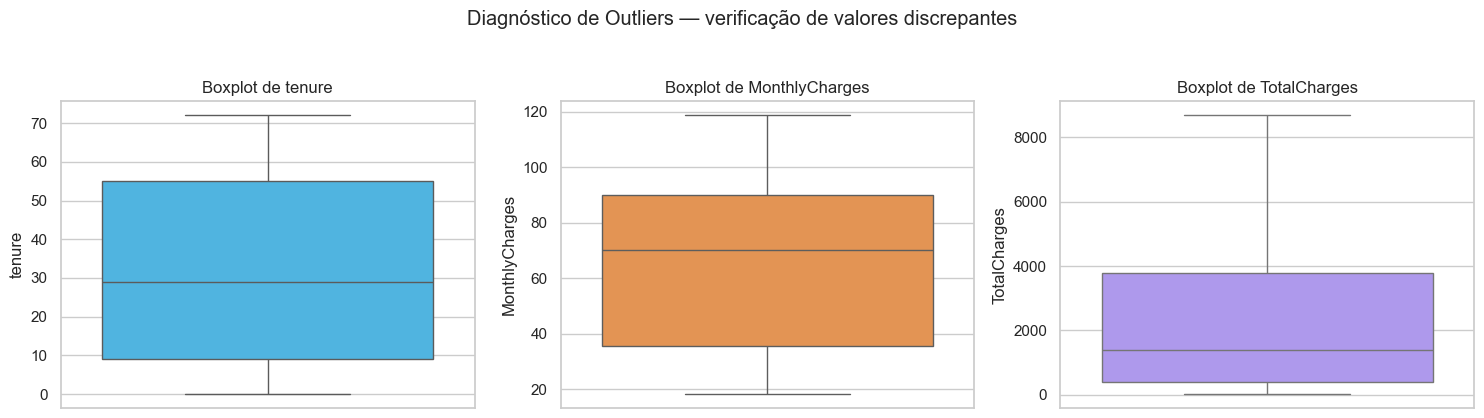

Outliers pelo critério IQR (1.5*IQR):
   tenure          faixa=[0.0, 72.0] | limites IQR=[-60.0, 124.0] | outliers=0
   MonthlyCharges  faixa=[18.2, 118.8] | limites IQR=[-46.0, 171.4] | outliers=0
   TotalCharges    faixa=[18.8, 8684.8] | limites IQR=[-4674.3, 8863.2] | outliers=0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cores = ["#38bdf8", "#fb923c", "#a78bfa"]
for ax, col, cor in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"], cores):
    sns.boxplot(data=df, y=col, color=cor, ax=ax)
    ax.set_title(f"Boxplot de {col}")
fig.suptitle("Diagnóstico de Outliers — verificação de valores discrepantes", y=1.04)
plt.tight_layout()
plt.show()

# Contagem objetiva pelo critério IQR (1.5 * IQR)
print("Outliers pelo critério IQR (1.5*IQR):")
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    q1, q3 = df[col].quantile(.25), df[col].quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((df[col] < lo) | (df[col] > hi)).sum())
    print(f"   {col:15s} faixa=[{df[col].min():.1f}, {df[col].max():.1f}] | limites IQR=[{lo:.1f}, {hi:.1f}] | outliers={n}")

**Interpretação e decisão:** pelo critério do IQR, as três variáveis têm **0 outliers** — os limites estatísticos são amplos (ex.: `tenure` varia de 0 a 72 meses, com limite superior do IQR em 124). São variáveis **limitadas por natureza** (meses de contrato, faixa de mensalidade). **Decisão: MANTER os dados, sem capping nem remoção.** Aplicar *capping* aqui seria um tratamento automático sem efeito real e sem justificativa — justamente o que a boa prática (e a rubrica) recomenda evitar.

### 3.4 Discretização para o Teorema de Bayes (feature engineering)

O Naive Bayes categórico exige atributos discretos. Criamos `TenureCluster` (Curto/Médio/Longo prazo) e `MonthlyChargesCluster` (Baixo/Médio/Alto gasto). A borda inferior dos bins é `-1` para **incluir** os clientes com `tenure = 0`.

In [8]:
df = prep.add_clusters(df)
print("TenureCluster:\n", df["TenureCluster"].value_counts(), "\n")
print("MonthlyChargesCluster:\n", df["MonthlyChargesCluster"].value_counts())

TenureCluster:
 TenureCluster
Longo Prazo (37m+)      3001
Curto Prazo (0-12m)     2186
Medio Prazo (13-36m)    1856
Name: count, dtype: int64 

MonthlyChargesCluster:
 MonthlyChargesCluster
Alto Gasto     3120
Medio Gasto    2188
Baixo Gasto    1735
Name: count, dtype: int64


## 4. Análise Exploratória (EDA)

Cada gráfico tem objetivo analítico e é seguido de uma interpretação embasada nos dados.

### 4.1 Distribuição da variável alvo

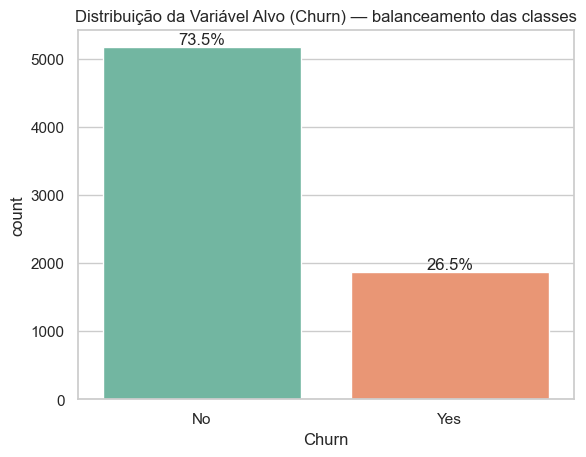

{'No': 0.735, 'Yes': 0.265}


In [9]:
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
total = len(df)
for p in ax.patches:
    ax.annotate(f"{p.get_height()/total*100:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Distribuição da Variável Alvo (Churn) — balanceamento das classes")
plt.show()
print(df["Churn"].value_counts(normalize=True).round(3).to_dict())

**Interpretação:** as classes são **desbalanceadas — 73,5% No e 26,5% Yes**. Isso é central: a acurácia sozinha engana (um modelo que sempre prevê "No" acerta 73,5% sem aprender nada). Por isso priorizamos **recall e F1 da classe Churn** e usamos `class_weight='balanced'` nos modelos de ML.

### 4.2 Variáveis categóricas vs. Churn

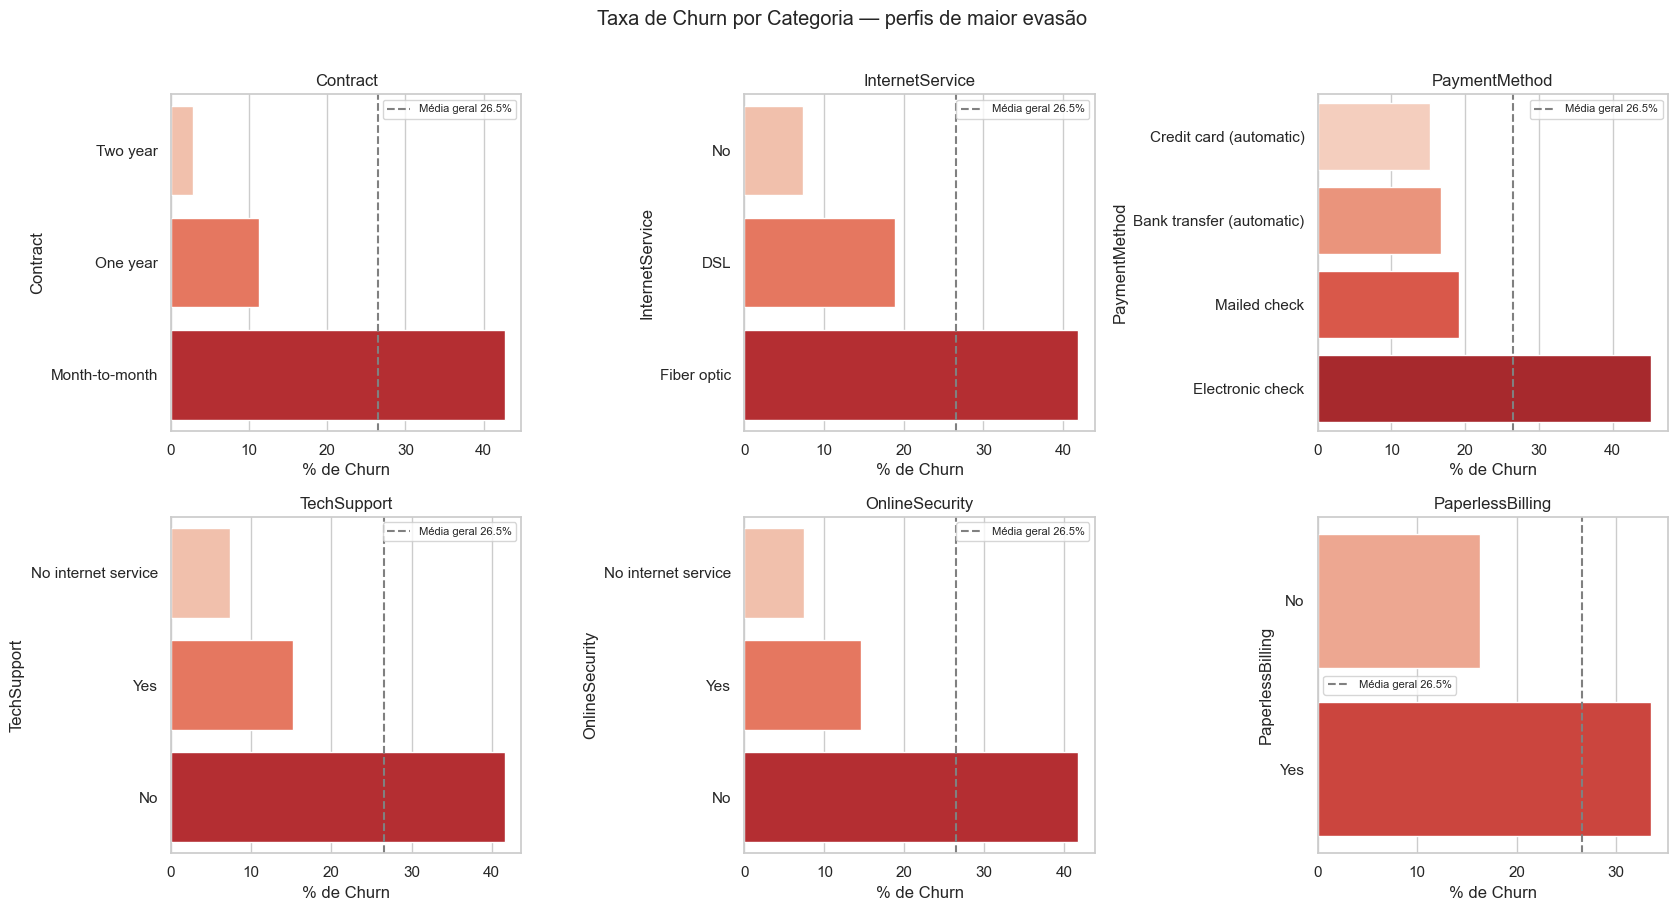

In [10]:
cats = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "PaperlessBilling"]
base = (df["Churn"] == "Yes").mean()
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), cats):
    rates = df.groupby(col, observed=True)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values()
    sns.barplot(x=rates.values * 100, y=rates.index, ax=ax, palette="Reds")
    ax.axvline(base * 100, color="gray", ls="--", label=f"Média geral {base*100:.1f}%")
    ax.set_title(col)
    ax.set_xlabel("% de Churn")
    ax.legend(fontsize=8)
fig.suptitle("Taxa de Churn por Categoria — perfis de maior evasão", y=1.01)
plt.tight_layout()
plt.show()

**Interpretação** (taxa de churn de cada categoria vs. a média geral de **26,5%**):
- **Contract** — fator mais forte: `Month-to-month` = **42,7%** de churn contra apenas **2,8%** em `Two year`. Contratos longos retêm o cliente.
- **InternetService** — `Fiber optic` = **41,9%** (preço/expectativa alta) vs. `No internet` = **7,4%**.
- **PaymentMethod** — `Electronic check` = **45,3%**, muito acima dos pagamentos automáticos (~15–17%).
- **TechSupport / OnlineSecurity** — não ter o serviço quase **triplica** o churn (~41% vs. ~15%).
- **PaperlessBilling** — `Yes` = **33,6%** vs. `No` = 16,3%.

Esses perfis sustentam tanto a modelagem bayesiana quanto a de ML a seguir.

### 4.3 Variáveis numéricas vs. Churn

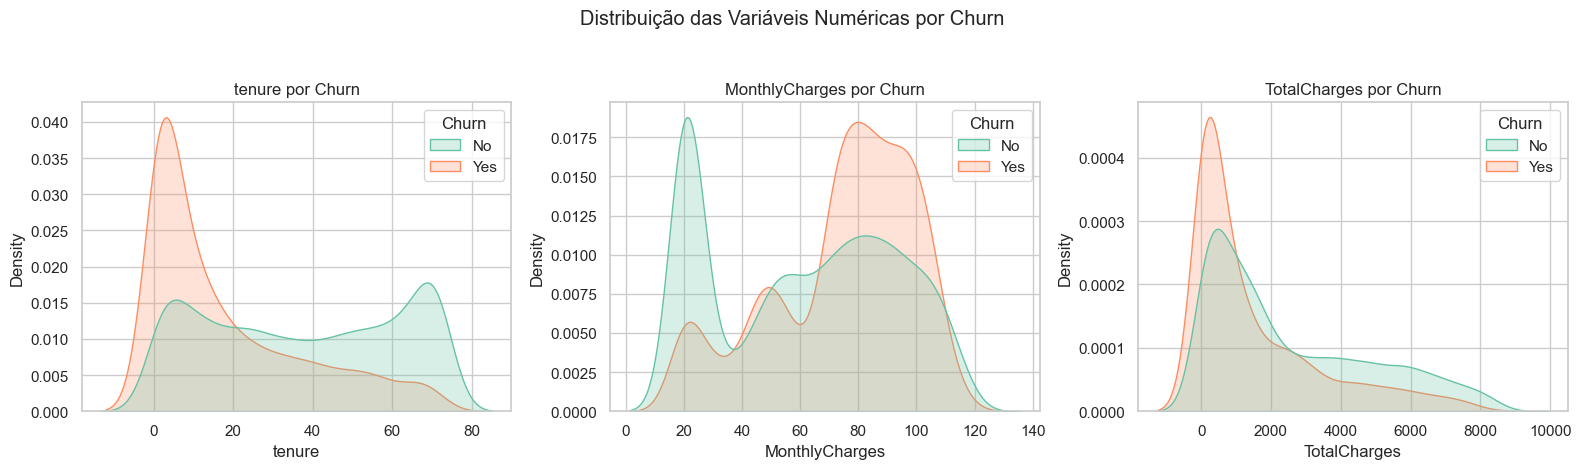

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.6            61.3        2552.9
Yes      18.0            74.4        1531.8


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False, palette="Set2", ax=ax)
    ax.set_title(f"{col} por Churn")
fig.suptitle("Distribuição das Variáveis Numéricas por Churn", y=1.04)
plt.tight_layout()
plt.show()
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(1))

**Interpretação:** quem dá churn tem **tenure médio de ~18 meses** (vs. 37,6 de quem fica) e **mensalidade mais alta** (74,4 vs. 61,3). O cliente que sai é tipicamente **novo e com conta cara** — coerente com os efeitos de `Fiber optic` e `Month-to-month`.

### 4.4 Correlação entre variáveis numéricas e o alvo

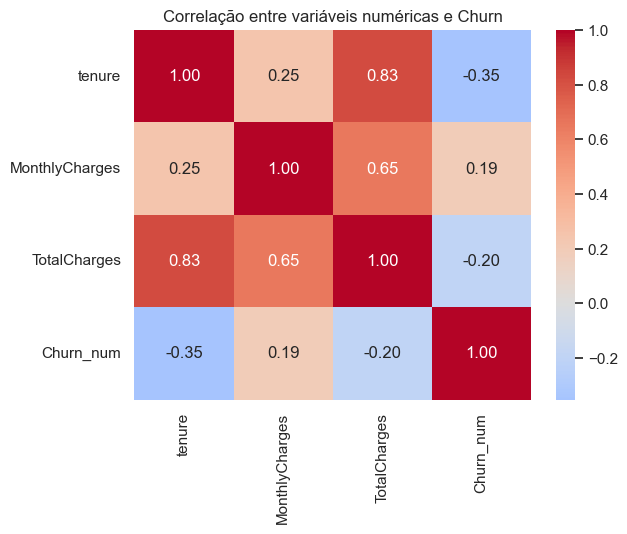

In [12]:
df_corr = df.copy()
df_corr["Churn_num"] = (df_corr["Churn"] == "Yes").astype(int)
corr = df_corr[["tenure", "MonthlyCharges", "TotalCharges", "Churn_num"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis numéricas e Churn")
plt.show()

**Interpretação:** `tenure` tem correlação **negativa** com churn (mais tempo de casa → menos evasão) e `MonthlyCharges`, **positiva**. `TotalCharges` é fortemente correlacionada a `tenure` (é praticamente tenure × mensalidade), trazendo informação **redundante** — motivo pelo qual não a incluímos no conjunto final de atributos dos modelos.

## 5. Preparação para Modelagem

Um **único split estratificado** (80/20, `stratify=Churn`, `random_state=42`) é compartilhado pelos **três métodos**, garantindo que Bayes, Regressão Logística e Random Forest sejam avaliados exatamente nas **mesmas linhas de teste** — comparação justa.

In [13]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["Churn"])
print("Treino:", train_df.shape[0], "| Teste:", test_df.shape[0])
print("Churn no treino:", round((train_df["Churn"] == "Yes").mean(), 3),
      "| no teste:", round((test_df["Churn"] == "Yes").mean(), 3))

# Alvo numérico: 1 = Yes = churn (classe positiva de interesse)
MAP = {"No": 0, "Yes": 1}
y_train = train_df["Churn"].map(MAP)
y_test = test_df["Churn"].map(MAP)

Treino: 5634 | Teste: 1409
Churn no treino: 0.265 | no teste: 0.265


## 6. Núcleo Probabilístico: Teorema de Bayes (implementação manual)

O **Teorema de Bayes** calcula a probabilidade *a posteriori* de uma classe dados os atributos observados:

$$P(C \mid X) = \frac{P(X \mid C)\,P(C)}{P(X)}$$

No nosso problema de churn:
- **C (classe)** — o valor de `Churn`: `Yes` ou `No`.
- **X (atributos)** — o perfil do cliente: `Contract`, `PaperlessBilling`, `InternetService`, `OnlineSecurity`, `TechSupport`, `PaymentMethod`, `TenureCluster`, `MonthlyChargesCluster`.
- **P(C)** — *a priori*: a frequência da classe no treino, $P(C) = \dfrac{N_C}{N}$.
- **P(X \mid C)** — *verossimilhança*. Pela hipótese **naive** (independência condicional entre atributos dada a classe): $P(X \mid C) = \prod_i P(x_i \mid C)$.
- **P(C \mid X)** — *a posteriori*, obtida normalizando os numeradores entre as classes (a evidência $P(X)$ é a soma deles).

**Suavização de Laplace** — para impedir que um atributo nunca observado em uma classe zere todo o produto, somamos 1 a cada contagem e o tamanho do vocabulário $V_i$ (nº de categorias distintas) ao denominador:

$$P(x_i \mid C) = \frac{\text{contagem}(x_i, C) + 1}{N_C + V_i}$$

A classe está em [`src/bayes.py`](../src/bayes.py) (importável também pelo dashboard).

In [14]:
X_bayes_train = train_df[prep.BAYES_FEATURES].astype(str)
X_bayes_test = test_df[prep.BAYES_FEATURES].astype(str)

bayes = ImplementacaoBayesManual()
bayes.treinar(X_bayes_train, train_df["Churn"])

print("Classes:", bayes.classes)
print("\nProbabilidades a priori P(C):")
for c, p in bayes.p_prior.items():
    print(f"   P(Churn={c}) = {p:.4f}")

Classes: ['No', 'Yes']

Probabilidades a priori P(C):
   P(Churn=No) = 0.7346
   P(Churn=Yes) = 0.2654


### 6.1 Verossimilhanças P(x | C)

Exemplo: a tabela de `P(Contract | Churn)`. Note como `Month-to-month` é muito mais provável entre quem dá churn.

In [15]:
tab = pd.DataFrame(bayes.p_conditional["Contract"]).round(4)
tab.index.name = "Contract"
print("P(Contract | Churn):")
tab

P(Contract | Churn):


,No,Yes
Contract,,
Month-to-month,0.4290,0.8858
Two year,0.3189,0.0267
One year,0.2521,0.0874


### 6.2 Exemplo interpretável — previsão passo a passo

Aplicamos o teorema "à mão" para um cliente do conjunto de teste, mostrando a multiplicação de cada termo.

In [16]:
exemplo = X_bayes_test.iloc[0].to_dict()
print("Cliente:", exemplo)
print("Classe real:", test_df["Churn"].iloc[0], "\n")

for c in bayes.classes:
    prob = bayes.p_prior[c]
    termos = [f"P(C={c})={prob:.4f}"]
    for col, val in exemplo.items():
        p = bayes.p_conditional[col][c].get(val, bayes._laplace_unseen(col, c))
        prob *= p
        termos.append(f"P({col}={val}|{c})={p:.3f}")
    print(f"[{c}]  " + "  *  ".join(termos))
    print(f"      numerador = {prob:.3e}\n")

posterior = bayes.predizer_probabilidade(exemplo)
print("Posteriori normalizada P(C|X):", {k: round(v, 4) for k, v in posterior.items()})
print("Previsão (MAP):", bayes.predizer(exemplo))

Cliente: {'Contract': 'Two year', 'PaperlessBilling': 'Yes', 'InternetService': 'Fiber optic', 'OnlineSecurity': 'Yes', 'TechSupport': 'Yes', 'PaymentMethod': 'Credit card (automatic)', 'TenureCluster': 'Longo Prazo (37m+)', 'MonthlyChargesCluster': 'Alto Gasto'}
Classe real: No 

[No]  P(C=No)=0.7346  *  P(Contract=Two year|No)=0.319  *  P(PaperlessBilling=Yes|No)=0.533  *  P(InternetService=Fiber optic|No)=0.347  *  P(OnlineSecurity=Yes|No)=0.336  *  P(TechSupport=Yes|No)=0.338  *  P(PaymentMethod=Credit card (automatic)|No)=0.249  *  P(TenureCluster=Longo Prazo (37m+)|No)=0.510  *  P(MonthlyChargesCluster=Alto Gasto|No)=0.397
      numerador = 2.484e-04

[Yes]  P(C=Yes)=0.2654  *  P(Contract=Two year|Yes)=0.027  *  P(PaperlessBilling=Yes|Yes)=0.753  *  P(InternetService=Fiber optic|Yes)=0.698  *  P(OnlineSecurity=Yes|Yes)=0.157  *  P(TechSupport=Yes|Yes)=0.168  *  P(PaymentMethod=Credit card (automatic)|Yes)=0.121  *  P(TenureCluster=Longo Prazo (37m+)|Yes)=0.200  *  P(MonthlyCharge

**Interpretação:** partimos da *a priori* da classe e multiplicamos pelas verossimilhanças de cada atributo; após normalizar, a classe de maior probabilidade é a previsão. Todo o cálculo é explícito, sem biblioteca de modelagem — demonstrando a compreensão do mecanismo.

### 6.3 Avaliação do Bayes no conjunto de teste

In [17]:
y_pred_bayes = pd.Series(bayes.predizer_lote(X_bayes_test)).map(MAP).values
print("Bayes Manual -> acc: %.4f | precisão: %.4f | recall: %.4f | f1: %.4f" % (
    accuracy_score(y_test, y_pred_bayes), precision_score(y_test, y_pred_bayes),
    recall_score(y_test, y_pred_bayes), f1_score(y_test, y_pred_bayes)))
print("Matriz de confusão [linha=real, coluna=previsto], rótulos [No, Yes]:")
print(confusion_matrix(y_test, y_pred_bayes))

# Persistência: a classe vem de src.bayes, então o .pkl é recarregável pelo dashboard
os.makedirs(prep.MODELS_DIR, exist_ok=True)
joblib.dump(bayes, os.path.join(prep.MODELS_DIR, "bayes_manual.pkl"))
print("\nbayes_manual.pkl salvo.")

Bayes Manual -> acc: 0.7495 | precisão: 0.5193 | recall: 0.7567 | f1: 0.6159
Matriz de confusão [linha=real, coluna=previsto], rótulos [No, Yes]:
[[773 262]
 [ 91 283]]

bayes_manual.pkl salvo.


## 7. Algoritmos de Classificação (Regressão Logística e Random Forest)

Ambos usam o **mesmo conjunto de 8 atributos** (`ML_FEATURES`). As categóricas são codificadas com `LabelEncoder` (mapeamento determinístico que **não usa o alvo**, portanto **sem data leakage**). A Regressão Logística recebe dados **padronizados** (`StandardScaler` ajustado **só no treino**); a Random Forest usa os dados brutos (árvores não precisam de escala). Usamos `class_weight='balanced'` para compensar o desbalanceamento.

In [18]:
# Encoders ajustados no domínio completo de categorias (mapeamento, não usa alvo)
encoders = {}
for col in prep.CATEGORICAL_FEATURES:
    encoders[col] = LabelEncoder().fit(df[col].astype(str))

def montar_X(frame):
    out = pd.DataFrame(index=frame.index)
    for col in prep.CATEGORICAL_FEATURES:
        out[col] = encoders[col].transform(frame[col].astype(str))
    for col in prep.NUMERIC_FEATURES:
        out[col] = frame[col].values
    return out[prep.ML_FEATURES]

X_train = montar_X(train_df)
X_test = montar_X(test_df)

# Scaler ajustado SÓ no treino (evita vazamento)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Modelo 1: Regressão Logística (dados escalados)
lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

# Modelo 2: Random Forest (dados brutos)
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced").fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Modelos treinados.")

Modelos treinados.


Regressão Logística    acc: 0.7268 | precisão: 0.4909 | recall: 0.7914 | f1: 0.6059
Random Forest          acc: 0.7594 | precisão: 0.5395 | recall: 0.6390 | f1: 0.5851


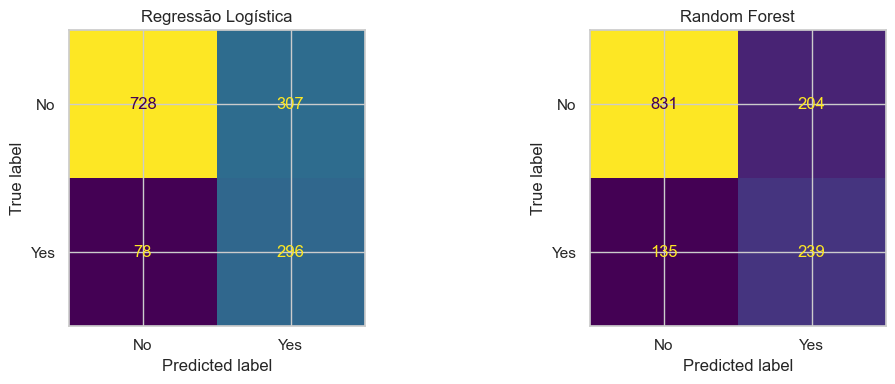

In [19]:
for nome, yp in [("Regressão Logística", y_pred_lr), ("Random Forest", y_pred_rf)]:
    print("%-22s acc: %.4f | precisão: %.4f | recall: %.4f | f1: %.4f" % (
        nome, accuracy_score(y_test, yp), precision_score(y_test, yp),
        recall_score(y_test, yp), f1_score(y_test, yp)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, nome, yp in [(axes[0], "Regressão Logística", y_pred_lr), (axes[1], "Random Forest", y_pred_rf)]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp), display_labels=["No", "Yes"]).plot(ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

**Interpretação:** a matriz de confusão revela o *trade-off*: com `class_weight='balanced'`, os modelos passam a **errar menos os clientes que de fato dão churn** (canto inferior direito), ao custo de mais falsos positivos. Para retenção de clientes, **recall na classe Churn costuma valer mais** que a acurácia bruta.

In [20]:
# Persistência dos artefatos de ML
joblib.dump(scaler, os.path.join(prep.MODELS_DIR, "scaler.pkl"))
joblib.dump(lr, os.path.join(prep.MODELS_DIR, "regressao_logistica.pkl"))
joblib.dump(rf, os.path.join(prep.MODELS_DIR, "random_forest.pkl"))
joblib.dump(encoders, os.path.join(prep.MODELS_DIR, "encoders.pkl"))
joblib.dump(prep.ML_FEATURES, os.path.join(prep.MODELS_DIR, "feature_names.pkl"))
joblib.dump(X_test, os.path.join(prep.MODELS_DIR, "X_test.pkl"))
joblib.dump(y_test, os.path.join(prep.MODELS_DIR, "y_test.pkl"))
print("Artefatos salvos em:", prep.MODELS_DIR)

Artefatos salvos em: C:\Users\Brenda\OneDrive\Documentos\GitHub\projetoAnaliseExploratoriaEProbabilistica\notebook\modelos


## 8. Comparação dos Três Métodos

Todos avaliados nas **mesmas linhas de teste**, com a classe positiva = `Churn = Yes`.

                     acuracia  precisao  recall      f1
Bayes Manual           0.7495    0.5193  0.7567  0.6159
Regressão Logística    0.7268    0.4909  0.7914  0.6059
Random Forest          0.7594    0.5395  0.6390  0.5851


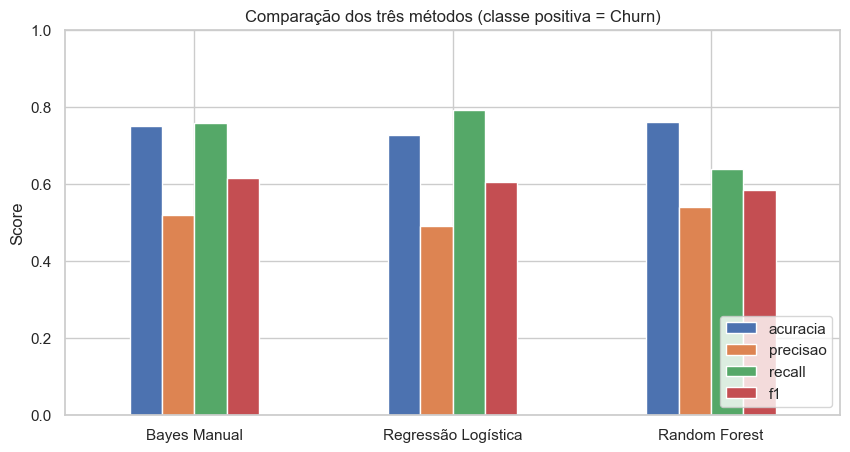

In [21]:
def metricas(y_true, y_pred):
    return {"acuracia": accuracy_score(y_true, y_pred),
            "precisao": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred)}

preds = {"Bayes Manual": y_pred_bayes, "Regressão Logística": y_pred_lr, "Random Forest": y_pred_rf}
tabela = pd.DataFrame({nome: metricas(y_test, yp) for nome, yp in preds.items()}).T.round(4)
print(tabela)

tabela.plot(kind="bar", figsize=(10, 5))
plt.title("Comparação dos três métodos (classe positiva = Churn)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [22]:
# Exporta um resumo de métricas para o relatório e o dashboard
metrics = {
    "n_train": int(len(train_df)), "n_test": int(len(test_df)),
    "priors": {k: round(v, 4) for k, v in bayes.p_prior.items()},
    "features_ml": prep.ML_FEATURES, "features_bayes": prep.BAYES_FEATURES,
    "models": {},
}
for nome, yp in preds.items():
    m = {k: round(v, 4) for k, v in metricas(y_test, yp).items()}
    m["cm"] = confusion_matrix(y_test, yp).tolist()
    metrics["models"][nome] = m

with open(os.path.join(prep.MODELS_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print(json.dumps(metrics, ensure_ascii=False, indent=2))

{
  "n_train": 5634,
  "n_test": 1409,
  "priors": {
    "No": 0.7346,
    "Yes": 0.2654
  },
  "features_ml": [
    "Contract",
    "PaperlessBilling",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "tenure",
    "MonthlyCharges"
  ],
  "features_bayes": [
    "Contract",
    "PaperlessBilling",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "TenureCluster",
    "MonthlyChargesCluster"
  ],
  "models": {
    "Bayes Manual": {
      "acuracia": 0.7495,
      "precisao": 0.5193,
      "recall": 0.7567,
      "f1": 0.6159,
      "cm": [
        [
          773,
          262
        ],
        [
          91,
          283
        ]
      ]
    },
    "Regressão Logística": {
      "acuracia": 0.7268,
      "precisao": 0.4909,
      "recall": 0.7914,
      "f1": 0.6059,
      "cm": [
        [
          728,
          307
        ],
        [
          78,
          296
        ]
      ]
    },
    "Rando

## 9. Conclusões

- O churn é majoritariamente explicado por **tipo de contrato, tempo de casa (`tenure`), serviço de internet e forma de pagamento**. O cliente típico de risco é **novo, com fibra, contrato mensal, pagamento por cheque eletrônico e mensalidade alta**.
- O **Teorema de Bayes manual** demonstra, de forma transparente e interpretável, como esses perfis elevam a probabilidade *a posteriori* de churn — sem depender de biblioteca de modelagem.
- **Regressão Logística e Random Forest** confirmam os mesmos padrões e oferecem predição automática; comparados ao Bayes, equilibram precisão e recall (ver tabela da Seção 8).
- **Limitações:** desbalanceamento das classes (26,5% de churn); uso de um subconjunto curado de atributos para manter o dashboard interpretável; e a suposição de independência condicional do Naive Bayes (raramente verdadeira na prática).
- Todos os artefatos são salvos em `notebook/modelos/` e consumidos pelo dashboard [`app.py`](../app.py).